In [1]:
# preamble
using Pkg; Pkg.activate(".")
using Revise
using Profile

using Dates
using Statistics, LinearAlgebra, SparseArrays
using TotalLeastSquares
using Rotations
using Interpolations
using DSP
using FFTW
using NCDatasets
using JLD2
using Printf
using Distributions

include("./read_lidar.jl")
using .read_lidar
using .read_lidar.stare
using .read_vecnav: read_vecnav_dict
import .chunks
read_stare_time  = Main.chunks.read_stare_time
read_stare_chunk = Main.chunks.read_stare_chunk
fit_offset = Main.chunks.fit_offset

include("./DopplerTurbulence.jl")
using .DopplerTurbulence

include("./timing_lidar.jl")
using .timing_lidar
include("./readers.jl")
using .NoaaDas: cat_dicts
# using MAT

using PythonPlot

  Activating project at `~/projects/lidar/ASTRAL2024`
  Activating project at `~/projects/lidar/ASTRAL2024`
    CondaPkg Found dependencies: /Users/deszoeks/.julia/packages/CondaPkg/lKlVY/CondaPkg.toml
    CondaPkg Found dependencies: /Users/deszoeks/.julia/packages/PythonCall/5WGSP/CondaPkg.toml
    CondaPkg Found dependencies: /Users/deszoeks/.julia/packages/PythonPlot/96RVm/CondaPkg.toml
    CondaPkg Found dependencies: /Users/deszoeks/.julia/packages/PythonPlot/oS8x4/CondaPkg.toml
    CondaPkg Dependencies already up to date


In [2]:
# utility functions extend Py[thon]Plot

# Methods for PyPlot or PythonPlot handle missing by wrapping in np.ma masked arrays.
if @isdefined(PythonPlot)
	import PythonPlot: PythonCall
	using PythonCall: Py

	# Extend the PythonCall converter to handle Missing arrays
	# Catch arrays with Missing elements and wrap them for PythonCall
	function PythonCall.Py(a::AbstractArray{Union{T, Missing}, N}) where {T<:Number, N}
		# Import numpy.ma (masked arrays)
		np = PythonCall.pyimport("numpy")
		
		# Create the data and mask (these are eager but efficient)
		data = coalesce.(a, zero(T))
		mask = ismissing.(a)
		
		# Return the NumPy masked array
		return np.ma.masked_array(data, mask=mask, dtype="float64")
	end

	function PythonCall.Py(a::AbstractArray{Union{T, Missing}, N}) where {T<:TimeType, N}
		# Import numpy.ma (masked arrays)
		np = PythonCall.pyimport("numpy")
		mdates = PythonCall.pyimport("matplotlib.dates")

		# Create the data and mask (these are eager but efficient)
		data = coalesce.(a, DateTime(1970,1,1))
		mask = ismissing.(a)
		
		# Return the NumPy masked array
		return np.ma.masked_array(data, mask=mask)
	end

    "close plots with close(\"all\")"
    close(s::String) = PythonCall.pyimport("matplotlib.pyplot").close(s)

elseif @isdefined(PyPlot)
	using PyCall
	using PyCall: PyObject
	# allow for plotting with missing values
	function PyCall.PyObject(a::Array{Union{T,Missing},N}) where {T,N}
		numpy_ma = PyCall.pyimport("numpy").ma
		pycall(numpy_ma.array, Any, coalesce.(a,zero(T)), mask=ismissing.(a))
	end
end

# "convert arrays with missings to masked python float64 arrays"
# msk(y) = ma.masked_invalid(np.array(replace(y, missing => NaN), dtype="float64"))


"plotf(f, x, args...)  function plot wrapper"
plotf(f, x, args...) = plot(x, f.(x), args...)

plotf

In [ ]:
# notebook-only helpers not yet migrated to DopplerTurbulence.
# Duplicates of module functions (pd, m2n, binavg, n2m, missmean, anom, hp, findindices,
# indavg, trigs, wtrue_trigs, wtrue, uniquepairs, allcross, rng, lidarindices, rangegate,
# displacements, rhopair) removed -- now provided by `using .DopplerTurbulence` (cell 0).

# utility functions
good(x) = !ismissing(x) & isfinite(x)

"""
    binavgvar(y, x, b; f=identity, w=y->1)
Bin average y(x) in bins b of coordinate x.
Returns bin mean and variance.
Skip missing by passing the optional function arguments
f(y) = ismissing(y) ? 0 : y;   w(y) = !ismissing(y)
"""
function binavgvar(y, x, b; f=identity, w=y->1)
    a     = zeros(length(b))
    a2    = zeros(length(b))
    count = zeros(length(b))
    for (i,x) in enumerate(x)
        bi = searchsortedlast(b, x)
        bi = clamp(bi, 1, length(b))
        a[bi]      += f(y[i])
        a2[bi]     += a[bi]^2
        count[bi]  += w(y[i])
    end
    avg = a ./count
    var = a2./count .- avg.^2
    return avg, var
end

# functions for masking and averaging data
noisethr = 1.05 # parameter for masking lidar data
# increase from 1.03 to 1.05 May 8, 2026

"result is x; set to missing iff i<thr"
masklowi(x, i, thr=noisethr) = i<thr ? missing : x
# NOTE: shadows DopplerTurbulence.masklowi (module default thr=1.03) on purpose,
# using the updated noisethr=1.05. Not pruned -- behavior differs from the module.

f(x) = x>noisethr # use intensity for x

# # mean Doppler velocity # OLD and tested
# function get_mdv(f, dopplervel)
#     X = missingnoise.(f, dopplervel)
#     mapslices(x->mean(skipmissing(x)), X; dims=2)[:]
# end

# Suggest only computing mdv (for motion removal) where
# there are nonnoise DVs for the whole chunk, so not to alias sampling differences.
# Then, only take the mean of the middle 5th quantile, to smoothly approximate the mode

"""
Motion from Doppler velocity, by inferring displacement of the median velocity 
by the platform motion at each time.
"""
function get_mdv(f, intensity, dopplervel)
    # levels with Doppler data at all times in the chunk
    goodlevels = findall(all(f, intensity; dims=1)[:]) # bool --> indices
    # median over whole chunk, continuously available levels
    chunkmedian = median(dopplervel[:,goodlevels]) # over both dims
    # median over vertical dim at each time
    timeslicemedian = median(dopplervel[:,goodlevels], dims=2)
    mdv = timeslicemedian .- chunkmedian
end
# UNTESTED!!
# This modification circumvents issues with sampling and better separates the motion estimate
# from the air velocities, assuming the median of the overall velocity distribution is 
# unchanged, and the Doppler velocity is merely shifted at each time by the platform motion,
# but with zero average shift since mean(motion) = median(motion) = 0.

remove_mdv(f, intensity, dopplervel) = dopplervel .- get_mdv(f, intensity, dopplervel)
remove_mdv!(f, intensity, dopplervel) = (dopplervel .-= get_mdv(f, intensity, dopplervel))

# diagnostics: empty/missing/finite status of chunk variables
isgoodnum(x) = !ismissing(x) && isfinite(x)

"average the good values of 2 numbers, fall back to either good value"
avg_good(x,y) = ifelse(isgoodnum(x) && isgoodnum(y), 0.5*(x+y), 
                    ifelse(isgoodnum(x), x, 
                        ifelse(isgoodnum(y), y, NaN) ) )

"diagnose array by printing size, number of missing, finite, and NaN values"
function diag_array(name, A)
    v = vec(A)
    n = length(v)
    nmiss = count(ismissing, v)
    nfin = count(isgoodnum, v)
    nnan = count(x -> !ismissing(x) && isnan(x), v)
    @printf("%-10s size=%-14s n=%6d empty=%5s missing=%6d finite=%6d nan=%6d\n",
        name, string(size(A)), n, string(n == 0), nmiss, nfin, nnan)
end

diag_array

In [5]:
# define periodic data types

# Wrap indices for periodic behavior
_wrap(x::Integer, n::Int) = mod1(x, n)
_wrap(x::AbstractRange{<:Integer}, n::Int) = mod1.(collect(x), n)
_wrap(x::AbstractArray{<:Integer}, n::Int) = mod1.(x, n)
_wrap(::Colon, ::Int) = (:)

# PeriodicVector periodically indexes
struct PeriodicVector{T}
    data::Vector{T}
end

# convenience constructor
PeriodicVector{T}(x, n::Integer) where {T} =
    PeriodicVector{T}(fill(x, n))

Base.ndims(p::PeriodicVector) = ndims(p.data) # literally 1
Base.size(p::PeriodicVector) = size(p.data)
Base.length(p::PeriodicVector) = length(p.data)
Base.eltype(::Type{PeriodicVector{T}}) where {T} = T

Base.getindex(p::PeriodicVector, i) =
    getindex(p.data, _wrap(i, length(p.data)))

Base.setindex!(p::PeriodicVector, v, i) =
    setindex!(p.data, v, _wrap(i, length(p.data)))
Base.setindex!(p::PeriodicVector, v::AbstractVector, i::Union{AbstractVector, AbstractRange}) =
    (p.data[_wrap(i, length(p.data))] .= v)
    
Base.iterate(P::PeriodicVector, state...) = iterate(P.data, state...)
Base.show(io::IO, P::PeriodicVector) = show(io, P.data)

# PeriodicMatrix periodically indexes the first dimension
struct PeriodicMatrix{T}
    data::Matrix{T}
end

PeriodicMatrix{T}(x, nrows::Integer, ncols::Integer) where {T} =
    PeriodicMatrix{T}(fill(x, nrows, ncols))

Base.ndims(p::PeriodicMatrix) = ndims(p.data) # literally 2
Base.size(P::PeriodicMatrix) = size(P.data)
Base.eltype(::Type{PeriodicMatrix{T}}) where {T} = T

Base.getindex(P::PeriodicMatrix, i, j...) =
    getindex(P.data, _wrap(i, size(P.data,1)), j...)

Base.setindex!(P::PeriodicMatrix, v, i, j...) =
    setindex!(P.data, v, _wrap(i, size(P.data,1)), j...)
Base.setindex!(P::PeriodicMatrix, v::AbstractArray, i::Union{AbstractVector, AbstractRange}, j...) =
    (P.data[_wrap(i, size(P.data,1)), j...] .= v)

    # add iteration, show
Base.iterate(P::PeriodicMatrix, state...) = iterate(P.data, state...)
Base.show(io::IO, P::PeriodicMatrix) = show(io, P.data)


In [ ]:
# functions for subsetting and finding the offset with max covariance
# newer: 2025-02
# MOVE to read_lidar.jl?

"""
return indices jl, js to subset windows dtl[jl], dts[js] st. 
limdtl[1]+offset <= dtl[jl] <= limdtl[2]+offset
limdtl[1]        <= dts[js] <= limdtl[2]
offset shifts the window in the long step coordinates
"""
# use with code for chunks found elsewhere
function offset_subset(dtl, dts, limdtl, offset=eltype(limdtl)(0))
    # index the long data set (gappy Halo) with absolute time deltas
    jl = findall(limdtl[1] .<= dtl-offset .<= limdtl[2])
    # comb the time indices out of VN dts
    js = findindices(dtl[jl] .- offset, dts) # findindices( needles, haystack )
    return jl, js
end

function offset_cov(dtl, dts, limdtl, offset, yl, ys)
    jl, js = offset_subset(dtl, dts, limdtl, offset)
    # try
    #     ii = isfinite.(yl[jl]) .&& isfinite.(ys[js]) # skip NaNs # sometimes breaks: arrays not broadcast to consistent size
    #     yl[jl][ii]
    # catch
    #     print("limdtl=$(limdtl) offset=$(offset) jl($(length(jl))), js($(length(js)))")
    # end
    # return cov = mean( skipmissing(yl[jl][ii] .* ys[js][ii]) ) # skip missings
    nn = @. good(yl[jl]) & good(ys[js])
    a_cov = cov(yl[jl][nn], ys[js][nn])
    # a_cov = mean( skipmissing(anom(yl[jl]) .* anom(ys[js])) ) # skip missings
    return a_cov
end

"find optimal offset timedelta (seconds) that syncs yl, ys"
function offset_range_covs(dtl, dts, limdtl, rangeoffset, yl, ys)
    covs = [ offset_cov(dtl, dts, limdtl, offset, yl, ys) 
                for offset in rangeoffset ]
end

"""
return the time offset that syncs dtl (Halo) and dts (VN) for the 
window limdt=[chunkdtstart, chunkdtend]
"""
function sync_offset(dtl, dts, yl, ys, limdt, rangeoffset=Second(0):Second(1):Second(200))
    rangecovs = offset_range_covs(dtl, dts, limdt, rangeoffset, yl, ys)
    maxcov, fm = findmax(rangecovs)
    bestoffset = rangeoffset[fm]
    return bestoffset, maxcov, std(rangecovs)
end

# load input data for doing the offset calculations
"load VN and 1 day of lidar timeangles"
function load_vn_lidar_data(thisdt, Vn=read_vecnav_dict())
    dts = Vn[:vndt] # short timesteps
    ys = Vn[:Roll]  # short-step data

    # read the lidar time axis for this day
    dtstamp = Dates.format(thisdt, dateformat"yyyymmdd")
    datapath = joinpath.(pwd(),"data",dtstamp)
    files = filter(startswith("Stare"), readdir(datapath))
    fullfiles = joinpath.(datapath, files)
    # also read the first hour of the next day
    nextdt = thisdt + Day(1)
    nextdatapath = joinpath.(pwd(), "data", Dates.format(nextdt, "yyyymmdd"))
    if isdir(nextdatapath)
        hour00 = readdir( nextdatapath ) |> filter(startswith("Stare")) |> filter(endswith("_00.hpl"))
        full25files = [fullfiles ; joinpath(nextdatapath, hour00[1])]
    else
        full25files = fullfiles
    end
    # read all times in those files
    ta, _, _ = read_lidar.read_streamlinexr_beam_timeangles(full25files)
    tatime = ta[:time] # lidar time axis, hours
    i20 = findfirst(tatime .> 20.0)
    wrap = (i20-1) .+ findall( tatime[i20:end] .< 5 )
    tatime[wrap] .+= 24.0 # increment wrapped times from next day by 24 h
    dtl = @. thisdt + Millisecond(round(Int64, tatime * 3_600_000)) # long timesteps
    yl = ta[:pitch] # long-step data
    return dtl, yl, dts, ys
end

load_vn_lidar_data

In [7]:
# read VectorNav
Vn = read_vecnav_dict()

Dict{Symbol, Vector} with 22 entries:
  :LinAcc1   => Float32[0.28455, -0.563547, 0.545289, -0.615101, 0.663306, -0.1…
  :Roll      => Float32[-0.684141, -0.711255, -0.714359, -0.761043, -0.767432, …
  :Latitude  => Float32[16.2633, 16.2633, 16.2633, 16.2633, 16.2633, 16.2633, 1…
  :vndt      => [DateTime("2024-04-29T05:25:42.128"), DateTime("2024-04-29T05:2…
  :time      => [DateTime("2023-03-29T13:17:44"), DateTime("2023-03-29T13:17:44…
  :Yaw       => Float32[-162.59, -162.574, -162.565, -162.549, -162.541, -162.5…
  :VelNED1   => Float32[5.05222, 5.04132, 5.05353, 5.04639, 4.93381, 4.93558, 4…
  :MagNED2   => Float32[0.09548, 0.100129, 0.09543, 0.095481, 0.093838, 0.09533…
  :Altitude  => Float32[-43.986, -43.986, -43.986, -43.986, -44.212, -44.212, -…
  :Quat1     => Float32[0.005692, 0.005927, 0.005941, 0.006337, 0.006396, 0.006…
  :VelNED2   => Float32[-0.280547, -0.279673, -0.27213, -0.271012, -0.272294, -…
  :MagNED0   => Float32[0.234275, 0.237392, 0.23345, 0.236116, 0.233466

In [8]:
# test load single wind file
# UV = NCDataset(joinpath("data/netcdf", "ekamsat_lidar_uv_20240428-20240604.nc")) # NCDataset
# UV = NCDataset(joinpath("data/netcdf", "ekamsat_lidar_uv_20240428-20240613.nc")) # lidar wind NCDataset
# test just 4-30 file of v1
uvpaths = ["data/netcdf", "data/netcdf/v1"]
uvpath = filter(p -> isfile(joinpath(p, "ekamsat_lidar_uv_20240430_v1.nc")), uvpaths)[1]
UV = NCDataset(joinpath(uvpath, "ekamsat_lidar_uv_20240430_v1.nc")) # lidar wind NCDataset

Dataset: data/netcdf/v1/ekamsat_lidar_uv_20240430_v1.nc
Group: /

Dimensions
   time = 144
   z_range = 150

Variables
  time   (144)
    Datatype:    DateTime (Float32)
    Dimensions:  time
    Attributes:
     units                = minutes since 2024-01-01
     standard_name        = time

  z_range   (150)
    Datatype:    Float32 (Float32)
    Dimensions:  z_range
    Attributes:
     units                = meter
     long_name            = elevation

  lat   (144)
    Datatype:    Float32 (Float32)
    Dimensions:  time
    Attributes:
     units                = deg
     long_name            = latitude

  lon   (144)
    Datatype:    Float32 (Float32)
    Dimensions:  time
    Attributes:
     units                = deg
     long_name            = longitude

  ut   (144 × 150)
    Datatype:    Float32 (Float32)
    Dimensions:  time × z_range
    Attributes:
     units                = m/s
     long_name            = true zonal wind speed
     comment              = variable ou

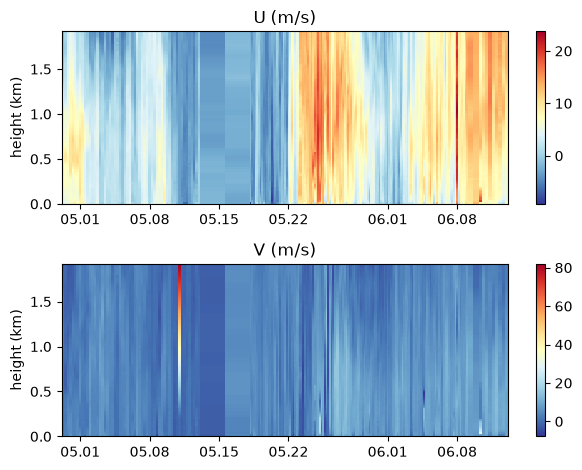

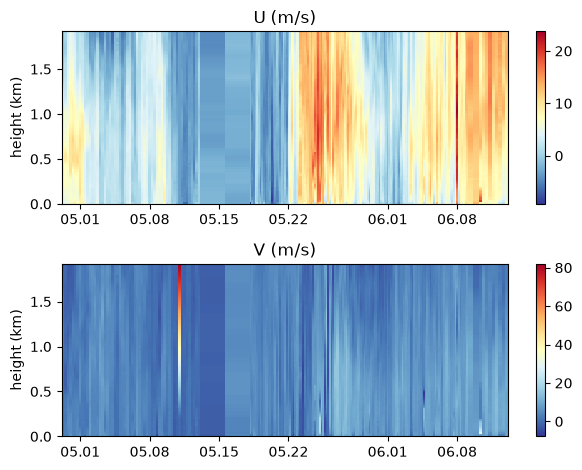

In [ ]:
UVsonde = Dataset(joinpath("data/netcdf", "EKAMSAT_RAOB_TGT_combined_80lev.nc"), "r");

In [ ]:
# load PSL met data
# candidate files in order of preference
files = [ "/mnt/c/Users/deszoeks/Data/EKAMSAT/PSL/netcdf/ASTRAL-nav-met-sea-flux-10min_RV-Thompson_20240428_R1_thru_20240613.nc",
          "~/Data/ASTRAL/PSL/netcdf/ASTRAL-nav-met-sea-flux-10min_RV-Thompson_20240428_R1_thru_20240613.nc",
          "/Users/deszoeks/Projects/ASTRAL/SSTcompare/data/PSL/ASTRAL-nav-met-sea-flux-10min_RV-Thompson_20240428_R1_thru_20240613.nc",
          "/Users/deszoeks/Projects/ASTRAL/mast/data/SSTcompare/PSL/netcdf/ASTRAL-nav-met-sea-flux-10min_RV-Thompson_20240428_R1_thru_20240613.nc" ]
filename = files[findfirst(isfile, files)]
psl = NCDataset(filename)
psltime = psl["time"][:] # @. DateTime(2024,1,1,0,0) + Second(round(Int, psl["time"][:]))
keys(psl) |> filter(k -> contains(string(k), "cog"))
psl["sog"];


sog (6192)
  Datatype:    Union{Missing, Float64} (Float64)
  Dimensions:  time
  Attributes:
   units                = m/s
   standard_name        = platform_speed_wrt_ground
   long_name            = speed-over-ground
   cdm_data_type        = physicalMeasurement
   instrument           = Hemisphere GPS VS-1000 system. Hemisphere MDA30 and MDA10 antenna, SN# 0824-7443-0010, 
   location             = starboard forward O2 deck rail
   _FillValue           = -9999.0
   axis                 = time


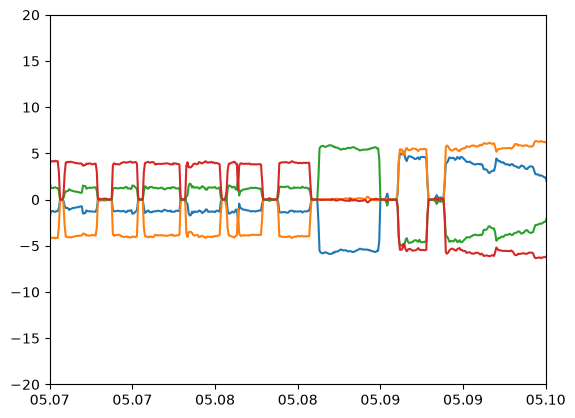

6-element view(::Vector{Union{Missing, Float64}}, [5347, 5348, 5349, 5350, 5351, 5352]) with eltype Union{Missing, Float64}:
 missing
 missing
 missing
 missing
 missing
 missing

In [ ]:
# interpolate over bad sonde velocity
its = findall(any(v-> v>25, UVsonde[:v][:,:], dims=1)[:] .| 
              any(v-> v>25, UVsonde[:u][:,:], dims=1)[:]   )
# size(UVsonde[:u])
clf()
plot(UVsonde[:u][:,:], UVsonde[:gp_height][:], marker=".")
plot(UVsonde[:v][:,:], UVsonde[:gp_height][:], marker=".")
xlim([-10, 5])
ylim([0, 400])
gcf()
# patch bad at height index 10 and above
usonde = UVsonde[:u][:,:]
vsonde = UVsonde[:v][:,:]
usonde[10:end, its] .= NaN
vsonde[10:end, its] .= NaN
# linearly interpolate from neighbors
it = its[1]
usonde[10:end, it] .= 0.5 * sum(usonde[10:end, [it-1, it+1]], dims=2)
vsonde[10:end, it] .= 0.5 * sum(vsonde[10:end, [it-1, it+1]], dims=2)
it = its[2]
usonde[:, it] .= 0.5 * sum(usonde[:, [it-1, it+1]], dims=2)
vsonde[:, it] .= 0.5 * sum(vsonde[:, [it-1, it+1]], dims=2)
gcf()
# putting back in the structure, attempts to save the readonly file.
# UVsonde[:u][:,it] .= usonde[:,it]
# UVsonde[:u][:,it] .= vsonde[:,it]
keys(UV)
#  "time"
#  "umet"
#  "ur"
#  "usog"       eastward speed of ship
#  "ut"         true zonal wind
#  "vmet"
#  "vr"
#  "vsog"       northward speed of ship
#  "vt"         true meridional wind
#  "z_range"

toofast = findall( map(x-> !ismissing(x) && x>20, psl[:sog][:]) ) # ship speed

Base.deg2rad(x::Missing) = missing
vog = psl[:sog][:] .* cosd.(psl[:cog][:]) # ship speed
uog = psl[:sog][:] .* sind.(psl[:cog][:])

# cp = uog .+ im*vog # complex

# convert DateTime to number for interp by subtracting the base time DateTime(2024,4,28,0,0,0)
basetime = minimum([psl[:time][1], UV[:time][1], UVsonde[:time][1]])
dt2te(dt) = (dt - basetime)/Millisecond(1000) # -> seconds since basetime
te2dt(te) = basetime + Second(te)
psl_te = dt2te.(psl[:time][:])
snd_te = dt2te.(UVsonde[:time][:])
lUV_te = dt2te.(UV[:time][:])

uog[toofast] .= missing
vog[toofast] .= missing

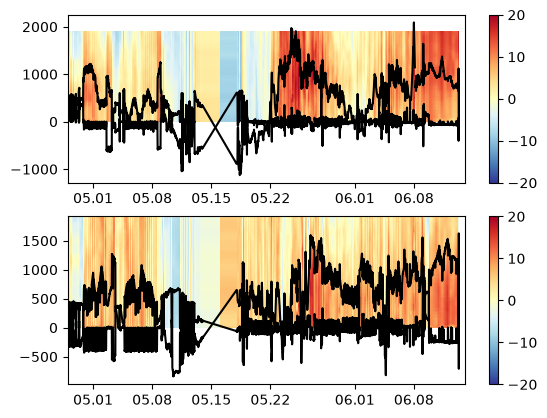

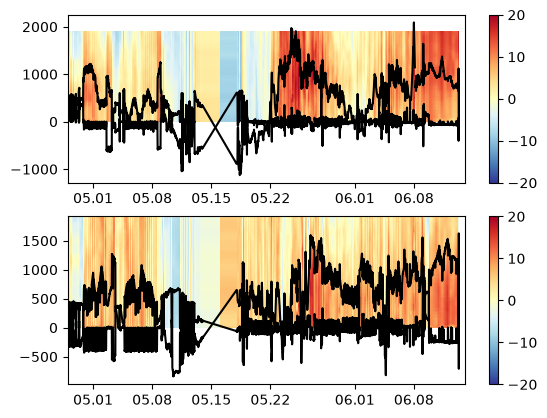

In [13]:
# temporal interpolation function for soundings
"""
    time_interp_vector((old_times, data), t::Real)

Vector-input kernel: Evaluates search indices and interpolation weights 
exactly ONCE per time point, then updates the height column.
"""
function time_interp_vector((old_times, data)::Tuple{AbstractVector, AbstractMatrix}, t::Real)
    idx = searchsortedfirst(old_times, t)
    
    # Boundary Conditions / Extrapolation
    if idx == 1
        return data[:, 1] # Returns a column vector view/copy
    elseif idx > length(old_times)
        return data[:, end]
    end
    
    t0, t1 = old_times[idx-1], old_times[idx]
    w = (t - t0) / (t1 - t0) # Calculated ONCE per time step
    
    # Allocates a clean, contiguous Vector for this column step
    # Highly SIMD optimizable down the height row layout
    return @views (1.0 - w) .* data[:, idx-1] .+ w .* data[:, idx]
end
# vector data method
function time_interp_vector((old_times, data)::Tuple{AbstractVector, AbstractVector}, t::Real)
    idx = searchsortedfirst(old_times, t)
    
    # Boundary Conditions / Extrapolation
    if idx == 1
        return data[1] # Returns a column vector view/copy
    elseif idx > length(old_times)
        return data[end]
    end
    
    t0, t1 = old_times[idx-1], old_times[idx]
    w = (t - t0) / (t1 - t0) # Calculated ONCE per time step
    
    # Allocates a clean, contiguous Vector for this column step
    # Highly SIMD optimizable down the height row layout
    return @views (1.0 - w) .* data[idx-1] .+ w .* data[idx]
end

# test the interpolation of the soundings
usnd_to_psl = stack(broadcast(t -> time_interp_vector((snd_te, usonde), t), psl_te))
vsnd_to_psl = stack(broadcast(t -> time_interp_vector((snd_te, vsonde), t), psl_te))

#= broadcasting example
# 1. Setup sample grid data
old_times = 1.0:5.0
data = rand(100, 5) # 100 heights, 5 time steps
new_times = 1.0:0.5:5.0

# 2. Map the vector kernel over time steps and collect straight into a 2D matrix
# reduce(hcat, ...) is heavily optimized in Julia to allocate a single flat matrix block
interpolated_matrix = reduce(hcat, map(t -> time_interp_vector((old_times, data), t), new_times))
# Or stack automatically splices the nested vectors along a new matrix dimension
interpolated_matrix = stack(broadcast(t -> time_interp_vector((old_times, data), t), new_times))
=#

clf()
subplot(2,1,1)
pcolormesh(psl[:time][:], UVsonde[:gp_height][:], usnd_to_psl .- uog', cmap=ColorMap("RdYlBu_r"),vmin=-20, vmax=20)
colorbar()
plot(psl[:time], 100*(usnd_to_psl[20,:].-uog), color="k")
plot(psl[:time], 100*uog, color="k")
gca().xaxis.set_major_formatter(PythonPlot.matplotlib.dates.DateFormatter("%m.%d"))
# xlim([DateTime(2024, 6, 7,20), DateTime(2024,6,8,4)])

subplot(2,1,2)
pcolormesh(psl[:time][:], UVsonde[:gp_height][:], vsnd_to_psl .- vog', cmap=ColorMap("RdYlBu_r"),vmin=-20, vmax=20)
colorbar()
plot(psl[:time], 100*(vsnd_to_psl[20,:].-vog), color="k")
plot(psl[:time], 100*vog, color="k")
gca().xaxis.set_major_formatter(PythonPlot.matplotlib.dates.DateFormatter("%m.%d"))
# xlim([DateTime(2024, 6, 7,20), DateTime(2024,6,8,8)])
gcf()
# looks ok

In [14]:
# get all the files, and all the unique hours of the files
allstarefiles = vcat( [ joinpath.("data",F, 
    filter( startswith(r"Stare_"), readdir(joinpath("data",F)) ) ) 
  for F in filter( startswith(r"20240"), readdir("data") ) ]... )

REm = match.(r"Stare_116_(\d{8}_\d{2}).hpl", allstarefiles)
dth = [ DateTime(r[1], dateformat"yyyymmdd_HH") for r in REm ]
unique(floor.(dth, Hour)) # all 991 are already unique

# also linked in ./data/all

991-element Vector{DateTime}:
 2024-04-28T00:00:00
 2024-04-28T01:00:00
 2024-04-28T02:00:00
 2024-04-28T03:00:00
 2024-04-28T04:00:00
 2024-04-28T05:00:00
 2024-04-28T06:00:00
 2024-04-28T07:00:00
 2024-04-28T08:00:00
 2024-04-28T09:00:00
 2024-04-28T10:00:00
 2024-04-28T11:00:00
 2024-04-28T12:00:00
 ⋮
 2024-06-12T19:00:00
 2024-06-12T20:00:00
 2024-06-12T21:00:00
 2024-06-12T22:00:00
 2024-06-12T23:00:00
 2024-06-13T00:00:00
 2024-06-13T01:00:00
 2024-06-13T02:00:00
 2024-06-13T03:00:00
 2024-06-13T04:00:00
 2024-06-13T05:00:00
 2024-06-13T06:00:00

In [15]:
"initialize a beams Dict with exactly nbeams beams with periodic 1st (time) index"
function init_periodic_beams(nbeams, ngates)
    # helper functions to initialize periodic data types
    PeriodicVector_missing(n) = PeriodicVector(
        Vector{Union{Float32,Missing}}(fill(missing, n)) )
    PeriodicMatrix_missing(nrows, ncols) = PeriodicMatrix(
        Matrix{Union{Float32,Missing}}(fill(missing, nrows, ncols)) )
    Vector_missing(n) = Vector{Union{Float32,Missing}}(fill(missing, n))

    beams = Dict(
        :time       => PeriodicVector_missing(nbeams), # decimal hours
        :azimuth    => PeriodicVector_missing(nbeams), # degrees
        :elevangle  => PeriodicVector_missing(nbeams),
        :pitch      => PeriodicVector_missing(nbeams),
        :roll       => PeriodicVector_missing(nbeams),
        :height     =>         Vector_missing(ngates), # center of gate
        :dopplervel => PeriodicMatrix_missing(nbeams,ngates), # m/s
        :intensity  => PeriodicMatrix_missing(nbeams,ngates), # SNR + 1
        :beta       => PeriodicMatrix_missing(nbeams,ngates) # m-1 sr-1  backscatter?
        )
end

# periodic buffer loop for data
nx = 4000 
nz = 80
x = zeros(nx,nz) # Doppler vel, backscatter, etc.
P = PeriodicMatrix( x )
dtx = PeriodicVector( fill(DateTime(0), nx) )

beams = init_periodic_beams(nx, nz)
beams[:time] isa Type # should be an instance, not a type

false

In [16]:
# get all times and a main list of chunks
# regardless of Stare file boundaries

# indices of gaps to find stare chunks
function stare.all_gaps(dt::Vector{DateTime})
    ien = findall( diff(dt) .> Second(36) )
    ist = ien .+ 1
    return ien, ist
end

if isfile("lidar_dt.jld2") 
    LidarDt = load("lidar_dt.jld2")
    # Dict: DateTime of each beam and indices of the start and end of staring chunks.
    kys = "ist", "ien", "dtime"
    ist, ien, dtime = ( LidarDt[k] for k in kys )
else
    # load and catenate time from the many Stare hpl files
    # construct and save a time vector of datetimes for all lidar beams
    # moved to save_lidar_dt.jl
    lidarstemdir = "./data"
    starefiles = filter(startswith("Stare_116_"), readdir(joinpath(lidarstemdir, "all")))
    ff = joinpath.(lidarstemdir, "all", starefiles)
    ta, _,_ = read_lidar.read_streamlinexr_beam_timeangles(ff) # slow
    
    day0 = floor(ta[:start_time][1], Day)
    dtime = day0 .+ Millisecond.(round.(Int64, 3600_000 .* ta[:time]))
    for j in findall(diff(ta[:time]) .< -1.0)
        dtime[(j+1):end] .+= Day(1) # increment days
    end

    ien, ist = all_gaps(dtime)
    ist = [1; ist]
    ien = [ien; length(dtime)]
    # [ist ien]
    
    @save "lidar_dt.jld2" dtime ist ien
    LidarDt = load("lidar_dt.jld2")
end

Base.Generator{Tuple{String, String, String}, var"#94#95"}(var"#94#95"(), ("ist", "ien", "dtime"))

In [17]:
# part out the data among the individual files
lidarstemdir = "./data"
starefiles = filter(startswith("Stare_116_"), readdir(joinpath(lidarstemdir, "all")))
ff = joinpath.(lidarstemdir, "all", starefiles)
timestep = 1.02 # s

if isfile("file_beam_inds.jld2")
    FileInds = load("file_beam_inds.jld2")
else # slow reload
    nfiles = length(ff)
    nbeams = zeros(Int32, nfiles)
    ngates = -1
    nheaderlines = 17
    # read number of lines for each file
    for (i,file) in enumerate(ff)
        h = read_lidar.read_streamlinexr_head(file)
        nlines = h[:nlines]
        ngates = h[:ngates]
        # beams could be rays or times
        nbeams[i] = round(Int, (nlines - nheaderlines) / (1+ngates)) # number of beams for each file
    end

    # indices for files slices
    bigind_file_end   = cumsum(nbeams)
    bigind_file_start = [0; bigind_file_end[1:end-1]] .+ 1

    # times, ibeam1, nbeams, hdr = read_lidar.read_streamlinexr_beam_times(ff) # slow bc. it rereads times
    # all( bigind_file_start .== ibeam1 ) # should be true
    [bigind_file_start nbeams bigind_file_end]
    @save "file_beam_inds.jld2" bigind_file_start nbeams bigind_file_end
    FileInds = load("file_beam_inds.jld2")
end

# load indices
LidarDt = load("lidar_dt.jld2")
length(LidarDt["dtime"]) == FileInds["bigind_file_end"][end] # should be true

true

In [ ]:
# read_streamlinexr_stare!(file_path, h, beams, bb, ...) moved into read_lidar.jl
# (now provided by `using .read_lidar`, cell 0)

In [19]:
# plotting functions

nannoise(noisemask, vel) = ismissing(noisemask) ? missing : (noisemask ? vel : missing)

"plot backscatter and velocity"
function pcolor_lidar_stare(fig, beams, LidarDt, st::Int, en::Int, noisethr=noisethr)
    dt = LidarDt["dtime"][st]
    dstr = Dates.format(dt, dateformat"yyyymmdd_HHMM")
    
    # get data
    height = beams[:height]
    # subset the variables for the present chunk
    time = beams[:time][st:en] # decimal hours
    kys = Symbol.(split("beta dopplervel intensity"))
    (beta, dopplervel, intensity) = (beams[k][st:en,:] for k in kys)
    noisemask = intensity .>= noisethr
    
    # remove the vertical-mean Doppler velocity
    # mdv = mapslices(x->mean(skipmissing(x)), dopplervel; dims=2)[:]
    # vel = dopplervel .- mdv # subtract mean heave vel
    # noisemask = intensity.>=noisethr
    f(x) = !ismissing(x) && isfinite(x) && x>noisethr
    vel = remove_mdv(f, intensity, dopplervel)

    clf()
    # plot_stare(time, height, beta, dopplervel, intensity)
    subplot(2,1,1)
    pcolormesh((time.%1)*60, height[4:end]/1e3, pd(beta[:,4:end]),
        cmap=ColorMap("RdYlBu_r"), vmin=0, vmax=0.2*maximum(beta[:,4:end]))
    ylim([0, 2])
    ylabel("height (km)")
    xlabel("time (minute)")
    title("$(Dates.format(dt, dateformat"yyyy-mm-dd HH:MM"))\nbackscatter")
    colorbar()

        # true for valid, false for noise
    subplot(2,1,2)
    pcolormesh((time.%1)*60, height[4:end]/1e3, pd(nannoise.(noisemask, vel)[:,4:end]),
        cmap=ColorMap("RdYlBu_r"), vmin=-2, vmax=2)
    ylim([0, 2])
    ylabel("height (km)")
    xlabel("time (minute)")
    title("Doppler velocity (m/s)")
    colorbar()
    
    tight_layout()
end

pcolor_lidar_stare

In [20]:
# load indices
bigind_file_ends = FileInds["bigind_file_end"]
bigind_file_starts  = FileInds["bigind_file_start" ]
iens             = LidarDt[ "ien"            ]
ists             = LidarDt[ "ist"            ]

# LidarDt["dtime"] # 3174132, one per second
dtime_st = LidarDt["dtime"][ists]
dtime_en = LidarDt["dtime"][iens]
length(iens)

5938

In [176]:
# define when VectorNav data is available

# already loaded

# bigind_file_ends    = FileInds["bigind_file_end"] # 991, one per file
# bigind_file_starts  = FileInds["bigind_file_start"]
# iens             = LidarDt[ "ien"            ]    # 5938, one per chunk
# ists             = LidarDt[ "ist"            ]

# # LidarDt["dtime"] # 3174132, one per second
# dtime_st = LidarDt["dtime"][ists]
# dtime_en = LidarDt["dtime"][iens]

icvn = findfirst( dtime_st .>= Vn[:vndt][1] ):findlast( dtime_en .<= Vn[:vndt][end] )
#dtime_st[1], Vn[:vndt][1], Vn[:vndt][end], dtime_en[end]

175:5605

In [177]:
# load_vn2_aligned loads vn2_aligned data for one chunk 
# from the daily sync NC files produced by LidarVNSync.write_daily_mdv_vn2!

"""
    load_vn2_aligned(ic, ist, ien, dtime; daily_dir) → Vector{Float64}

Read VectorNav heave velocity aligned to lidar time for chunk `ic` from the
daily sync NC file produced by `LidarVNSync.write_daily_mdv_vn2!`.

Returns `(ien - ist + 1)` `Float64` values aligned position-exactly with
`dopplervel[ist:ien, :]`.  Elements are `NaN` where VN coverage was
insufficient or when the daily file / chunk row is absent.
Check `any(isfinite, result)` before using as heave correction.

Daily files: `daily_dir/mdv_vn2_sync_YYYYMMDD.nc`
where YYYYMMDD is the calendar date of `dtime[ist]`.
"""
function load_vn2_aligned(ic::Integer, ist::Integer, ien::Integer,
        dtime::AbstractVector{DateTime};
        daily_dir = joinpath("data", "vn_sync_chunk_daily"),
)
    nbeams = ien - ist + 1
    vn2 = fill(NaN, nbeams)
    pitch = zeros(Float64, nbeams)
    roll  = zeros(Float64, nbeams)
    start_day = Date(dtime[ist])
    nc_path = joinpath(daily_dir,
        "mdv_vn2_sync_$(Dates.format(start_day, dateformat"yyyymmdd")).nc")
    isfile(nc_path) || return vn2
    NCDataset(nc_path, "r") do ds
        cics = ds["chunk_ic"][:]
        k = findfirst(cics .== Int32(ic))
        isnothing(k) && return
        t0 = Int(ds["time_start_idx"][k])
        t1 = Int(ds["time_end_idx"][k])
        n_use = min(t1 - t0 + 1, nbeams)
        vn2[  1:n_use] .= Float64.(coalesce.(ds["vn2_aligned"][t0:(t0 + n_use - 1)], NaN))
        pitch[1:n_use] .= Float64.(coalesce.(ds["pitch"      ][t0:(t0 + n_use - 1)], NaN))
        roll[ 1:n_use] .= Float64.(coalesce.(ds["roll"       ][t0:(t0 + n_use - 1)], NaN))
    end
    return vn2, pitch, roll
end


load_vn2_aligned

In [178]:
# postproduction functions: load JLD and compute se_epsilon

"propagate slope uncertainty to epsilon uncertainty via first-order derivative"
function se_epsilon_from_A_seA(A, se_A)
    out = similar(A, Union{Missing,Float64})
    for i in eachindex(A)
        ai = A[i]
        sei = se_A[i]
        if ismissing(ai) || ismissing(sei)
            out[i] = missing
        elseif !isfinite(ai) || !isfinite(sei) || ai <= 0 || sei < 0
            out[i] = missing
        else
            out[i] = 1.5 * epsilon(ai) * (sei / ai)
        end
    end
    out
end

"tiny loader util: read output JLD and return se_epsilon + relative se"
function load_se_epsilon_jld(outfile)
    dat = load(outfile)

    A_in = haskey(dat, "A") ? dat["A"] : (haskey(dat, "A_tmp") ? dat["A_tmp"] : nothing)
    seA_in = haskey(dat, "se_A") ? dat["se_A"] : (haskey(dat, "se_A_tmp") ? dat["se_A_tmp"] : nothing)
    epsi_in = haskey(dat, "epsi") ? dat["epsi"] : nothing

    if isnothing(A_in) || isnothing(seA_in) || isnothing(epsi_in)
        error("Missing required keys. Need epsi and either (A, se_A) or (A_tmp, se_A_tmp).")
    end

    se_epsilon = se_epsilon_from_A_seA(A_in, seA_in)
    rel_se_epsilon = similar(se_epsilon, Union{Missing,Float64})
    for i in eachindex(se_epsilon)
        sei = se_epsilon[i]
        ei = epsi_in[i]
        if ismissing(sei) || ismissing(ei) || !isfinite(sei) || !isfinite(ei) || ei <= 0
            rel_se_epsilon[i] = missing
        else
            rel_se_epsilon[i] = sei / ei
        end
    end

    return (se_epsilon=se_epsilon, rel_se_epsilon=rel_se_epsilon, A=A_in, se_A=seA_in, epsi=epsi_in)
end

finite_summary(X) = begin
    vals = Float64[x for x in X if !ismissing(x) && isfinite(x)]
    isempty(vals) ? (n=0, p50=missing, p90=missing, p99=missing) :
        (n=length(vals), p50=quantile(vals, 0.50), p90=quantile(vals, 0.90), p99=quantile(vals, 0.99))
end


finite_summary (generic function with 1 method)

In [179]:
# TEST loading 1 chunk
 
nx = 4000
nz = 80
# x = zeros(nx,nz) # Doppler vel, backscatter, etc.
# P = PeriodicMatrix( x )
# dtx = PeriodicVector( fill(DateTime(0), nx) )
beams = init_periodic_beams(nx, nz)

# TKE dissipation output data array
epsi_tmp = zeros(Float64, length(iens), nz) .- 9 # dissipation for chunks; -9 is missing value

# choose chunk from VN-covered chunk indices
kic = 1                      # or any 1:length(icvn)
ic = icvn[kic]
ist = ists[ic]
ien = iens[ic]

# find which file contains that chunk (same idea as multi-file loop)
ifile = findlast(bigind_file_starts .<= ist)
isnothing(ifile) && error("No file start found for ic=$(ic), ist=$(ist)")

if ien > bigind_file_ends[ifile]
    error("Chunk ic=$(ic) spans files; one-file diagnostic expects a single containing file")
end

bigind_file_start = bigind_file_starts[ifile]
bigind_file_end   = bigind_file_ends[ifile]
print("\nfile $(ifile) $(bigind_file_start)---$(bigind_file_end) chunk ")
# file 30 91843---93740 chunk 

# load that file
h = read_lidar.read_streamlinexr_head(ff[ifile])
bb = bigind_file_start:bigind_file_end
read_streamlinexr_stare!(ff[ifile], h, beams, bb)

# now process selected chunk
dt_chunk = LidarDt["dtime"][ist]
dopplervel, pitch, roll, vn0, vn1, vn2, Ur, Vr, mdv =
    read_stare_chunk(dt_chunk, beams, Vn, UV, ist, ien, nz)

# load VN heave aligned to this chunk's lidar times from daily sync NC
vn2_aligned, pitch_aligned, roll_aligned = load_vn2_aligned(ic, ist, ien, LidarDt["dtime"])
# had failed because daily sync file time series are empty with length 0

vn_ok = any(isfinite, vn2_aligned)

println("\nchunk diagnostics")
@printf("ist=%d ien=%d nt=%d\n", ist, ien, ien - ist + 1)
diag_array("dopplervel", dopplervel)
diag_array("pitch", pitch)
diag_array("roll", roll)
diag_array("vn0", vn0)
diag_array("vn1", vn1)
diag_array("vn2", vn2)
diag_array("Ur", Ur)
diag_array("Vr", Vr)
diag_array("mdv", mdv)
@printf("vn2_aligned: n_finite=%d/%d  vn_ok=%s\n",
    count(isfinite, vn2_aligned), length(vn2_aligned), string(vn_ok))

# UV dimension/time diagnostics for this chunk
nuvt = length(UV["time"])
ur_sz = size(UV[:ur])
vr_sz = size(UV[:vr])
@printf("UV dims: ur=%s vr=%s time=%d\n", string(ur_sz), string(vr_sz), nuvt)
@printf("UV time eltype=%s, first=%s, last=%s\n", string(eltype(UV["time"])), string(UV["time"][1]), string(UV["time"][end]))
@printf("chunk dt first=%s, last=%s\n", string(LidarDt["dtime"][ist]), string(LidarDt["dtime"][ien]))

if any(isgoodnum.(Ur)) && any(isgoodnum.(Vr)) # there is wind data
    # use vn2_aligned (synced heave) when available; fall back to mdv
    heave = vn_ok ? vn2_aligned : Float64.(coalesce.(mdv, NaN))
    w = dopplervel .- heave
    D2bin, rhobin, A, noise = D2_rho_stare(w, pitch*pi/180, roll*pi/180, Ur, Vr)

    for iz in eachindex(A)
        a = A[iz]
        if ismissing(a)
            epsi_tmp[ic, iz] = -3   # code for missing/insufficient structure-function fit
        elseif a >= 0
            epsi_tmp[ic, iz] = epsilon(a)
        else
            epsi_tmp[ic, iz] = -1   # code for slope A < 0
        end
    end
else
    epsi_tmp[ic, :] .= -4           # code for missing wind (only this chunk)
end



file 30 91843---93740 chunk 
chunk diagnostics
ist=92432 ien=92968 nt=537
dopplervel size=(537, 80)      n= 42960 empty=false missing= 24960 finite= 18000 nan=     0
pitch      size=(537,)         n=   537 empty=false missing=     0 finite=   537 nan=     0
roll       size=(537,)         n=   537 empty=false missing=     0 finite=   537 nan=     0
vn0        size=(537,)         n=   537 empty=false missing=     0 finite=   537 nan=     0
vn1        size=(537,)         n=   537 empty=false missing=     0 finite=   537 nan=     0
vn2        size=(537,)         n=   537 empty=false missing=     0 finite=   537 nan=     0
Ur         size=(537, 80)      n= 42960 empty=false missing=     0 finite= 42960 nan=     0
Vr         size=(537, 80)      n= 42960 empty=false missing=     0 finite= 42960 nan=     0
mdv        size=(537,)         n=   537 empty=false missing=     0 finite=   537 nan=     0
vn2_aligned: n_finite=537/537  vn_ok=true
UV dims: ur=(144, 150) vr=(144, 150) time=144
UV time e

In [217]:
# short run 4-29 12 to 4-30 00; ic=ist:285
# where VN is unsynced but seems to improve
# consistency of epsilon results.

# computes 20 chunks in 34 s

# VN correction only <==> MDV_FALLBACK=false; MDV_STRICT=false
MDV_FALLBACK = false
MDV_STRICT = false | true

CALC_SIGMA_ANGLES = false
PLOT_STRUCTURE_FN = false

clf()

if false | true
# periodic buffer for data within chunks
nx = 4000
nz = 80
nbinmax = 100 # risk of overrunning the buffer
beams = init_periodic_beams(nx, nz)

# don't overwrite existing
if true || !isdefined(Main, :D2_tmp) && !isdefined(Main, :R2_tmp) && !isdefined(Main, :sigma_roll_tmp)    
    # TKE dissipation output data array for chunks
    D2_tmp      = Array{Union{Missing,Float64}}(missing, length(iens), nz, nbinmax)
    rho_tmp     = Array{Union{Missing,Float64}}(missing, length(iens), nz, nbinmax)
    epsi_tmp = zeros(Float64, length(iens), nz) .- 9 # -9 is missing
    # fit quality metrics (saved alongside epsilon)
    A_tmp       = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    se_A_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    nbins_tmp   = zeros(Int, length(iens), nz)
    nrho_tmp    = zeros(Int, length(iens), nz)
    R2_tmp      = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    RMSE_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    A_lo_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    A_hi_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    epsi_lo_tmp = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    epsi_hi_tmp = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    sigma_pitch_tmp = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    sigma_roll_tmp = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
end

ifile_loaded = 0

# for ic in findall(t-> DateTime(2024,4,30) <= t < DateTime(2024,5,1), dtime_st)

# loop all chunk time indices, record missing for no Vn data
for ic in eachindex(dtime_st)[195:end]
    
    ist = ists[ic]
    ien = iens[ic]

    # map this chunk to its start file
    ifile_needed = findlast(bigind_file_starts .<= ist)
    isnothing(ifile_needed) && error("No file contains ist=$ist")

    # initialize so first load can jump directly toward needed file
    if ifile_loaded == 0
        ifile_loaded = ifile_needed - 1
        bigind_file_end = 0
    end

    # load one or more files until this chunk [ist, ien] is fully available in beams
    while (ifile_loaded < ifile_needed) || (ien > bigind_file_end)
        ifile_loaded += 1
        if ifile_loaded > length(ff)
            error("Ran out of files while loading chunk ic=$ic, ist=$ist, ien=$ien")
        end

        bigind_file_start = bigind_file_starts[ifile_loaded]
        bigind_file_end   = bigind_file_ends[ifile_loaded]

        h  = read_lidar.read_streamlinexr_head(ff[ifile_loaded])
        bb = bigind_file_start:bigind_file_end
        read_streamlinexr_stare!(ff[ifile_loaded], h, beams, bb)

        println("\nic=$ic ifile_loaded=$ifile_loaded bigind_file=$bigind_file_start-$bigind_file_end")
    end
    print("$(ist)-$(ien) ")

    dt_chunk = LidarDt["dtime"][ist]
    dopplervel, pitch, roll, _, _, _, Ur, Vr, _ = read_stare_chunk(dt_chunk, beams, Vn, UV, ist, ien)
    # fallback Ur, Vr with interpolated radiosonde relative wind speed...
    chunk_te = dt2te(dt_chunk) # time elapsed of chunk (s since 2024-4-28 00:00:00) 
    # time_interp_vector((te_sonde, var_sonde), t) interpolates var_sonde to time t based on te_sonde
    Usnd_chunk = time_interp_vector((snd_te, usonde), chunk_te)
    Vsnd_chunk = time_interp_vector((snd_te, vsonde), chunk_te)
    # interpolate ship relative wind to chunk time
    uog_chunk = time_interp_vector((psl_te, uog), chunk_te) # scalar
    vog_chunk = time_interp_vector((psl_te, vog), chunk_te) # scalar
    Urelsnd_chunk = Usnd_chunk .- uog_chunk
    Vrelsnd_chunk = Vsnd_chunk .- vog_chunk
    # average sounding with lidar U, or use the whichever is available if one is bad
    for iz in axes(Ur)[2]
        for i in axes(Ur)[1]
            Ur[i,iz] = avg_good(Ur[i,iz], Urelsnd_chunk[iz])
            Vr[i,iz] = avg_good(Vr[i,iz], Vrelsnd_chunk[iz])
        end
    end

    # use vn2_aligned (synced heave) when available; fall back to mdv
    vn2_aligned, pitch_aligned, roll_aligned = load_vn2_aligned(ic, ist, ien, LidarDt["dtime"])
    
    if CALC_SIGMA_ANGLES
        # fails when angles are missing
        σ_pitch = π / 180 * std( pitch_aligned[isfinite.(pitch_aligned)] ) # radians
        σ_roll  = π / 180 * std( roll_aligned[ isfinite.( roll_aligned)] )
    else
        σ_pitch = π / 180 * 2.0 # nominal 2 degree -> radians
        σ_roll  = π / 180 * 2.0
    end
    if !MDV_STRICT && any(isfinite, vn2_aligned)
        heave = vn2_aligned
        pitch = pitch_aligned # use VN synced angles
        roll = roll_aligned
    elseif MDV_STRICT || MDV_FALLBACK # fallback to mdv-based heave estimate
        valid_dv = isgoodnum.(dopplervel)
        jj = vec(all(valid_dv, dims=1))
        heave = any(jj) ? mean(dopplervel[:, jj], dims=2)[:] : fill(NaN, size(dopplervel, 1))
        pitch[:] .= 0 .* pitch  # zero pitch and roll if not using synced VN
        roll[:]  .= 0 .* roll
    else
        epsi_tmp[ic, :] .= -5 # code for missing heave data (both vn2_aligned and mdv fallback)
        continue # skip this chunk if vn2_aligned is not available, rather than using mdv fallback
    end

    if any(isgoodnum.(Ur)) && any(isgoodnum.(Vr)) # there is wind data
        len = minimum((
            size(dopplervel, 1),
            length(pitch),
            length(roll),
            size(Ur, 1),
            size(Vr, 1),
            length(heave),
        ))
        if len < 3
            epsi_tmp[ic, :] .= -3
            nbins_tmp[ic, :] .= 0
            continue
        end

        w = dopplervel[1:len, :] .- heave[1:len]
        # D2bin, rhobin, A_fit, noise, R2_fit, RMSE_fit, nbins_fit, se_A_fit, A_ci_lo, A_ci_hi, epsi_ci_lo, epsi_ci_hi, nrho = 
        #     D2_rho_stare_qc(w, pitch[1:len]*pi/180, roll[1:len]*pi/180, 
        #                     Ur[1:len, :], Vr[1:len, :],
        #                     σ_pitch, σ_roll )
        D2bin, rhobin, A_fit, noise, R2_fit, RMSE_fit, nbins_fit, se_A_fit, A_ci_lo, A_ci_hi, epsi_ci_lo, epsi_ci_hi, nrho = 
            D2_rho_small_disp(w, pitch[1:len]*pi/180, roll[1:len]*pi/180, 
                            Ur[1:len, :], Vr[1:len, :],
                            σ_pitch, σ_roll )
        if PLOT_STRUCTURE_FN
            plot(rhobin, D2bin); xlabel("rho"); ylabel("D2")
        end

        nb = size(D2bin, 1)
        D2_tmp[ ic, :, 1:nb] .= D2bin'
        rho_tmp[ic, :, 1:nb] .= rhobin'

        A_tmp[ic, :] .= A_fit
        se_A_tmp[ic, :] .= se_A_fit
        nbins_tmp[ic, :] .= nbins_fit
        R2_tmp[ic, :] .= R2_fit
        RMSE_tmp[ic, :] .= RMSE_fit
        A_lo_tmp[ic, :] .= A_ci_lo
        nrho_tmp[ic, :] .= nrho
        A_hi_tmp[ic, :] .= A_ci_hi
        epsi_lo_tmp[ic, :] .= epsi_ci_lo
        epsi_hi_tmp[ic, :] .= epsi_ci_hi
        sigma_pitch_tmp[ic, :] .= σ_pitch
        sigma_roll_tmp[ic, :] .= σ_roll

        for iz in eachindex(A_fit)
            a = A_fit[iz]
            if ismissing(a)
                epsi_tmp[ic, iz] = -3   # code for missing/insufficient structure-function fit
            elseif a >= 0
                epsi_tmp[ic, iz] = epsilon(a)
            else
                epsi_tmp[ic, iz] = -1   # code for slope A <= 0
            end
        end
    else
        epsi_tmp[ic, :] .= -4           # code for missing wind (only this chunk)
        nbins_tmp[ic, :] .= 0
    end
end

# save: epsilon plus fit metrics
epsi = epsi_tmp
height = beams[:height]
A = A_tmp
se_A = se_A_tmp
nbins = nbins_tmp
nrho = nrho_tmp
sigma_pitch = sigma_pitch_tmp
sigma_roll = sigma_roll_tmp
savetime = Dates.format(now(), dateformat"yyyymmdd_HHMM")
# @save joinpath("epsilon_data","epsi_stare_vn_chunks_r$(savetime).jld") epsi dtime_st dtime_en height A se_A nbins R2_tmp RMSE_tmp A_lo_tmp A_hi_tmp epsi_lo_tmp epsi_hi_tmp nrho sigma_pitch sigma_roll
end
gcf()

# TLS shows slight improvement in troublesome cases
# need to update prod run with TLS


ic=195 ifile_loaded=33 bigind_file=100140-103338

ic=195 ifile_loaded=34 bigind_file=103339-106537
103115-103632 103633-104169 104170-104706 104707-105243 105244-105780 105781-106317 
ic=201 ifile_loaded=35 bigind_file=106538-109736
106318-106835 106836-107372 107373-107909 107910-108446 108447-108983 108984-109520 
ic=207 ifile_loaded=36 bigind_file=109737-112937
109521-110038 110039-110575 110576-111112 111113-111649 111650-112186 112187-112723 
ic=213 ifile_loaded=37 bigind_file=112938-116137
112724-113242 113243-113779 113780-114316 114317-114853 114854-115390 115391-115927 
ic=219 ifile_loaded=38 bigind_file=116138-119338
115928-116446 116447-116983 116984-117520 117521-118057 118058-118594 118595-119131 
ic=225 ifile_loaded=39 bigind_file=119339-122538
119132-119650 119651-120187 120188-120724 120725-121261 121262-121798 121799-122335 
ic=231 ifile_loaded=40 bigind_file=122539-125739
122336-122853 122854-123390 123391-123927 123928-124464 124465-125001 125002-125538 
ic=237 ifil

Figure(<py Figure size 640x480 with 0 Axes>)

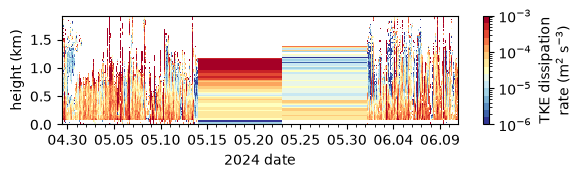

Python: Text(24.33658854166668, 0.5, 'height (km)')

In [230]:
# plot epsilon
function plot_epsilon(epsi, dtime_st, height)
    filt_eps(x) = x > 0 ? x : NaN
    it = findall(any(epsi.>0, dims=2)[:])
    cmap = get_cmap("RdYlBu_r", 15)
    norm = PythonPlot.matplotlib.colors.LogNorm(vmin=1e-6, vmax=1e-3)
    mdates = PythonPlot.matplotlib.dates
    date_fmt = mdates.DateFormatter("%m.%d")
    minor_locator = mdates.DayLocator(interval=1)      # Tick every single day
    major_locator = mdates.DayLocator(interval=5)      # Tick/Label every 5 days (change to 7 if preferred)

    ax = gca()
    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_minor_locator(minor_locator)
    ax.xaxis.set_major_formatter(date_fmt)
    pc = pcolormesh(dtime_st[it[3:end]], height/1e3,
        filt_eps.(epsi[it[3:end],:])';
        norm=norm,
        cmap=cmap, shading="auto", rasterized=true)
    cb = fig.colorbar(pc, ax=ax)
    cb.set_label("TKE dissipation\nrate (m\$^2\$ s\$^{-3}\$)")
    # ax.set_title("epsilon (m^2/s^3)"); 
    ax.set_xlabel("2024 date"); ylabel("height (km)")
end

gcf()
subplot(3,1,1)
plot_epsilon(epsi, dtime_st, height)

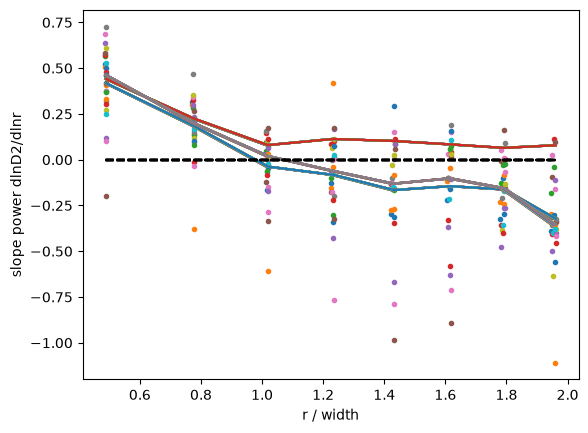

Python: Text(24.33658854166667, 0.5, 'slope power dlnD2/dlnr')

In [149]:
# examine structure functions
# D2bin, rhobin
# available from loop by interactive soft scoping

# test the transfer function for finite sample volume correction
# function inv_transfer_fcn(r2, dS2; rangegate2=rangegate^2)
#     zi = (1.22/4)^2 # 1/4 # Gaussian window variance factor
#     xi = 1/12 # rectangular window variance factor
#     width2 = xi*dS2 + zi*rangegate2
#     (1.0 + width2/r2)^(1/3)
# end

rbin = rhobin.^1.5
r2 = rbin.^2
dS2 = (Ur[1,:].^2 .+ Vr[1,:].^2)[:] * timestep^2
# width increases for larger lidar sample volume filter scale
width2 = (1.22/4 * rangegate)^2 .+
          1/12 * dS2 .+
         (0.00*pi*rng.(1:80)).^2
w = sqrt.(width2)[iiz]
normr = rhobin[1:8,iiz]./w' # r normalized by width
inv_transfer_fcn(r2, width2) = (1.0 + width2/r2)^(1/3)

Txf = inv_transfer_fcn.(r2, dS2') # matrix(r, height)
D2corr = D2bin .* Txf
D2comp     = D2bin  ./ mean(D2bin[2:3,:],dims=1)  ./ (rhobin./rhobin[2])
D2compcorr = D2corr ./ mean(D2corr[2:3,:],dims=1) ./ (rhobin./rhobin[2])

# power d log D2 / d log r
# should be 0 in inertial range, 2/3 in filtered range
X = (diff(log.(D2comp[1:9,iiz]), dims=1) ./
     diff(log.(  rbin[1:9,iiz]), dims=1))

iiz = 6:32 # expect good retrievals

#=
clf()
subplot(1,2,1)
loglog(rbin[:,iiz], D2bin[ :,iiz],"-", linewidth=0.5)
loglog(rbin[:,iiz], D2corr[:,iiz],".-", linewidth=0.5)
loglog(rbin[:,1], 0.1 ./Txf, color="k", linewidth=1)
plot([1e0, 1e2].^1.5, [0.5e-2, 0.5e0], "k--")
ylim([7e-3, 0.12]); xlim([5, 150])
ylabel("D2"); xlabel("r")

subplot(1,2,2)
plot(rbin[:,iiz], D2bin[ :,iiz],"-", linewidth=0.5)
plot(rbin[:,iiz], D2corr[:,iiz],".-", linewidth=0.5)
plot(rbin[:,1], 0.1 ./Txf, color="k", linewidth=1)
ylim([0, 0.12]); xlim([0, 150])
# gcf()
=#
# plot compensated structure functions
#=
clf()
subplot(1,2,1)
loglog(rhobin[:,iiz], D2comp[:,iiz],".-", linewidth=0.5)
# loglog(rhobin[:,iiz], D2compcorr[:,iiz],".-", linewidth=0.5)
# ylim([7e-3, 0.12]); 
# xlim([5, 150])
ylabel("D2"); xlabel("rho")
title("compensated")

subplot(1,2,2)
# loglog(rhobin[:,iiz], D2comp[:,iiz],".-", linewidth=0.5)
loglog(rhobin[:,iiz], D2compcorr[:,iiz],".-", linewidth=0.5)
# ylim([0, 0.12]);
# xlim([0, 150])
title("compensated and corrected")
# gcf()

# "$(size(D2bin)) $(size(rhobin)) $(size(D2corr))"
=#

# plot volume overfiltering in r from slope of compensated structure function
#=
ir = 3
clf()
subplot(2,2,1)
hist(X)
title("overfiltered -->")
subplot(2,2,2)
plot(sqrt.(dS2[iiz]), rng.(iiz), ".")
xlabel("U dt"); ylabel("range")
subplot(2,2,3)
rcor = cor(sqrt.(dS2[iiz]), X[ir,:])
plot(sqrt.(dS2[iiz]), X[ir,:], ".")
title("r=$(rcor)")
xlabel("U dt"); ylabel("overfiltering")
subplot(2,2,4)
rcor = cor(rng.(iiz), X[ir,:])
plot(rng.(iiz), X[ir,:], ".")
title("r=$(rcor)")
xlabel("z"); ylabel("overfiltering")
tight_layout()
=#

pos(x) = x > 0
filt(x) = pos(x) ? x : 0.0

clf()
plot(normr, X, ".")
plot(normr, sum(filt, X, dims=2)./sum(pos, X, dims=2))
plot(normr, mean(X, dims=2))
plot(normr, median(X, dims=2))
plot(normr, 0*X[:,1], "k--")
xlabel("r / width"); 
ylabel("slope power dlnD2/dlnr")
# width is chosen correctly
# D2(rbin[3:8]) are insensitive to volume filtering,
# and relatively insensitive to 

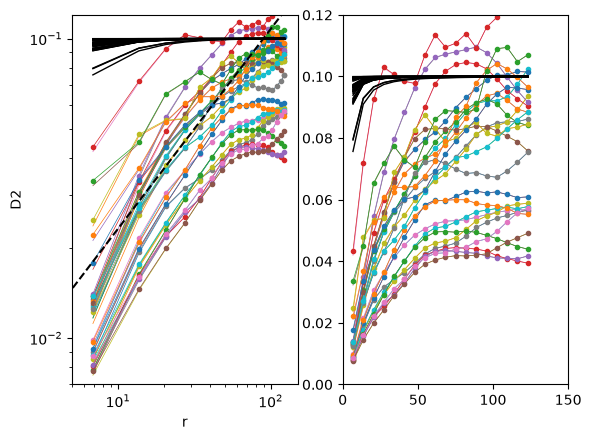

Python: (0.0, 150.0)

In [156]:
clf()
subplot(1,2,1)
loglog(rbin[:,iiz], D2bin[ :,iiz],"-", linewidth=0.5)
loglog(rbin[:,iiz], D2corr[:,iiz],".-", linewidth=0.5)
loglog(rbin[:,1], 0.1 ./Txf, color="k", linewidth=1)
plot([1e0, 1e2].^1.5, [0.5e-2, 0.5e0], "k--")
ylim([7e-3, 0.12]); xlim([5, 150])
ylabel("D2"); xlabel("r")

subplot(1,2,2)
plot(rbin[:,iiz], D2bin[ :,iiz],"-", linewidth=0.5)
plot(rbin[:,iiz], D2corr[:,iiz],".-", linewidth=0.5)
plot(rbin[:,1], 0.1 ./Txf, color="k", linewidth=1)
ylim([0, 0.12]); xlim([0, 150])

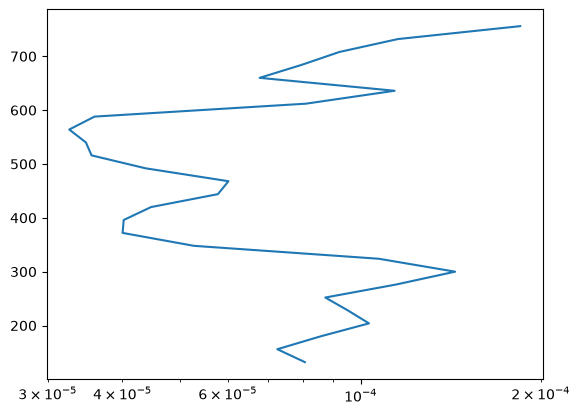

Python: [<matplotlib.lines.Line2D object at 0x5d371f50c10>]

In [ ]:
# compute structure function slope:
# get noise at each height from good indices for linear fit.

# parameters
k0 = 3
k1 = 8
# separations are spaced evenly in r, not rho
fac = 0.6 # factor to avoid energy-containing range
noisequantile = 0.2 # quantile of noise to subtract from D2

# test procedure
noise, slope_ = get_noise(rhobin, D2bin) # subract noise from D2
plot(sort(noise),".")
isf = isfinite.(noise) .& (noise.>0)
# bestnoise = max(0, quantile(@view(noise[isf]), noisequantile))
bestnoise = median(@view(noise[isfinite.(noise)])) # indistinguishable from zero
Afit = get_slope(rhobin, D2bin .- 0*bestnoise)
# get epsilon from slope A at each height
epsi = epsilon.(Afit)

clf()
# plot(slope_[iiz], rng.(iiz))
# plot(Afit[iiz], rng.(iiz))
# plot(A[iiz], rng.(iiz))
semilogx(get_epsilon(D2bin,rhobin)[iiz], rng.(iiz))

In [ ]:
# plot scaled and compensated D2 structure function
C2 = 2.0
d2_scaled(D2, rho, epsilon, nu=1.5e-5) = D2/(epsilon^(2/3) * rho)
# plot d2_scaled vs. r/η or rho*η^(-2/3)
# the linear property of rho doesn't matter, but we already combined
# horizontal and vertical displacements into rho

kolmogorov_length_scale(epsilon; nu=1.5e-5) = (nu^3 / epsilon)^0.25 # η
kolmogorov_vel_scale(epsilon; nu=1.5e-5) = sqrt(epsilon * nu)

"""
    epsilon, noise, n = get_epsilon_noise(rho, D2)
Get noise from min D2 in small rho bins, subtract noise,
compute epsilon from compensated D2/rho.
Inputs binned by rho (rho = r^(2/3), ascending order)
D2 = A*rho + noise  =>  (D2-noise)/rho = A = C2 * epsilon^(2/3)
Avoid near-noise small-rho bins that give D2_comp = 0.
! something wrong -- returns all missing !
"""
function get_epsilon_noise(rho::AbstractVector, D2::AbstractVector)
    C2 = 2.0

    ii = isgoodnum.(D2) .& isgoodnum.(rho)
    n = sum(ii)
    fii = findall(ii)
    if (n < 3) || !any(ii[1:5]) # not enough valid bins, and no valid bins in smallest 5 rho bins
        return NaN, NaN, n
    else
        noise = minimum(D2[findall(ii[1:5])]) # already means of bins
        D2_comp = (D2[fii[6:end]] .- noise) ./ rho[fii[6:end]]
        # Filter out bins with low signal-to-noise ratio
        pos = D2_comp .> 0 # stricter threshold biases epsilon too high
        if sum(pos) < 3
            return NaN, noise, n
        end
        epsilon = (median(D2_comp[pos]) / C2)^1.5
        return epsilon, noise, n
    end
end
sum(isgoodnum.(D2_tmp))

141444

In [ ]:

sz = size(rho_tmp)[1:2]
epsi = -ones(sz)
noise = -ones(sz)
nfit = zeros(Int, sz)
for i in CartesianIndices(sz)
    epsi[i], noise[i], nfit[i] = @views get_epsilon_noise(rho_tmp[i, :], D2_tmp[i, :])
end

#= too many lines, slow, hard to see
for i in CartesianIndices(sz)
    y = (D2_tmp[i,:] .- noise[i]) ./ rho_tmp[i,:]
    ii = .!ismissing.(y) .& .!ismissing.(rho_tmp[i,:]) .& (y .> 0)
    if any(ii)
        plot(rho_tmp[i,ii], y[ii], linewidth=0.5)
    end
end
yscale("log")
gcf()
=#
sum(epsi[iit,4:end] .>= 0)

0

In [ ]:
# plot level 7 and see spectra for high and low epsilon
ii = (epsi[213:285,7] .> 5e-4)
ii = (epsi_tmp[213:285,7] .> 5e-4)
clf()
plot(rho_tmp[(213:285)[ii],7,:]', D2_tmp[(213:285)[ii],7,:]' .- noise[(213:285)[ii],7]', color="r", linewidth=0.5)
plot(rho_tmp[(213:285)[.!ii],7,:]', D2_tmp[(213:285)[.!ii],7,:]' .- noise[(213:285)[.!ii],7]', color="k", linewidth=0.5)
# xlim(0, 10)
gcf()
# sum(ii)

MethodError: MethodError: Py(::Matrix{Missing}) is ambiguous.

Candidates:
  Py(a::AbstractArray{Union{Missing, T}, N}) where {T<:TimeType, N}
    @ Main ~/Projects/lidar/ASTRAL2024/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y513sZmlsZQ==.jl:22
  Py(a::AbstractArray{Union{Missing, T}, N}) where {T<:Number, N}
    @ Main ~/Projects/lidar/ASTRAL2024/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y513sZmlsZQ==.jl:10

Possible fix, define
  Py(::AbstractArray{Missing, N}) where N


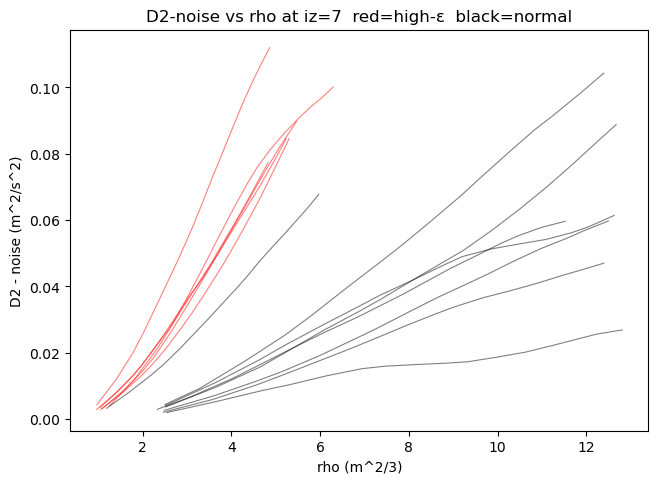

In [ ]:
clf()
for ic in ic_bad[1:min(8,end)]
    rr = rho_tmp[ic, iz_diag, :]
    dd = D2_tmp[ic, iz_diag, :]
    nn = coalesce(noise[ic, iz_diag], 0.0)
    ii = .!ismissing.(rr) .& .!ismissing.(dd) .& (dd .> nn)
    if any(ii)
        plot(collect(skipmissing(rr[ii])), collect(skipmissing(dd[ii])) .- nn, 
             color="r", alpha=0.5, linewidth=0.8)
    end
end
for ic in ic_ok[1:min(8,end)]
    rr = rho_tmp[ic, iz_diag, :]
    dd = D2_tmp[ic, iz_diag, :]
    nn = coalesce(noise[ic, iz_diag], 0.0)
    ii = .!ismissing.(rr) .& .!ismissing.(dd) .& (dd .> nn)
    if any(ii)
        plot(collect(skipmissing(rr[ii])), collect(skipmissing(dd[ii])) .- nn,
             color="k", alpha=0.5, linewidth=0.8)
    end
end
xlabel("rho (m^2/3)"); ylabel("D2 - noise (m^2/s^2)")
title("D2-noise vs rho at iz=$iz_diag  red=high-ε  black=normal")
gcf()

In [ ]:

# DIAGNOSTIC: why is rho 10x smaller for high-epsilon chunks?
# Two candidate causes:
#   A. Short chunk (small nt) → max Δit is small → max wind advection is small
#   B. Wind speed near zero or NaN from UV at those chunk times

iz_diag = 7
epsi_hi = 5e-4
ic_range = 213:285

ic_bad = [ic for ic in ic_range if epsi[ic, iz_diag] > epsi_hi]
ic_ok  = [ic for ic in ic_range if 0 < epsi[ic, iz_diag] < epsi_hi]

# helper: look up mean wind speed from UV for a chunk time window
function chunk_windspeed(ist, ien, iz; uv=UV, dtime=LidarDt["dtime"])
    t_start = dtime[ist]
    t_end   = dtime[ien]
    uvt = uv["time"][:]
    jj = findall(t_start .<= uvt .<= t_end)
    isempty(jj) && return NaN, NaN
    ur_col = uv[:ur][:, jj]
    vr_col = uv[:vr][:, jj]
    # iz indexes the lidar range gate; UV may have different z dimension
    nz_uv = size(ur_col, 1)
    iz_uv = min(iz, nz_uv)
    ur_vals = filter(isfinite, Float64.(ur_col[iz_uv, :]))
    vr_vals = filter(isfinite, Float64.(vr_col[iz_uv, :]))
    ur_mean = isempty(ur_vals) ? NaN : mean(ur_vals)
    vr_mean = isempty(vr_vals) ? NaN : mean(vr_vals)
    return ur_mean, vr_mean
end

println("ic   nt    U(m/s)  V(m/s) |UV|(m/s)  max_rho_obs  max_rho_pred(wind)  sigma_p(°)  epsi")
println("---  ----  ------  ------  --------  -----------  ------------------  ----------  ----")
for ic in sort([ic_bad; ic_ok[1:min(5,end)]])
    ist  = ists[ic]
    ien  = iens[ic]
    nt   = ien - ist + 1
    ur, vr = chunk_windspeed(ist, ien, iz_diag)
    wspd = isfinite(ur) && isfinite(vr) ? sqrt(ur^2 + vr^2) : NaN
    # expected rho from wind advection at max lag (nt-1 seconds), capped at Lscale_max
    rho_pred = isfinite(wspd) ? min(wspd * (nt - 1) * timestep, 3500.0)^(2/3) : NaN
    rho_obs  = maximum(skipmissing(rho_tmp[ic, iz_diag, :]))
    sp       = coalesce(sigma_pitch_tmp[ic, iz_diag], NaN) * 180/pi
    ei       = epsi[ic, iz_diag]
    tag = ei > epsi_hi ? " ← bad" : ""
    @printf("%-4d %-5d  %6.2f  %6.2f  %7.2f   %9.3f    %9.3f           %5.2f°  %.2e%s\n",
            ic, nt, isfinite(ur) ? ur : NaN, isfinite(vr) ? vr : NaN, wspd,
            rho_obs, rho_pred, sp, ei, tag)
end


ic   nt    U(m/s)  V(m/s) |UV|(m/s)  max_rho_obs  max_rho_pred(wind)  sigma_p(°)  epsi
---  ----  ------  ------  --------  -----------  ------------------  ----------  ----
213  519      2.93   -0.92     3.07      12.394      138.017            2.00°  2.27e-04
214  537      2.76   -1.26     3.03      12.498      140.096            2.00°  1.03e-04
215  537      2.64   -0.28     2.65      12.394      128.151            2.00°  8.11e-05
216  537      3.23   -0.64     3.29      12.809      148.016            2.00°  3.22e-05
217  537      3.15   -1.05     3.32      12.672      148.890            2.00°  1.50e-04
222  537      3.57   -1.48     3.86       5.467      164.618            2.00°  6.16e-04 ← bad
229  537      1.92    0.06     1.93       4.863      103.474            2.00°  1.05e-03 ← bad
239  537      0.53    0.82     0.97       4.826       65.608            2.00°  5.54e-04 ← bad
240  537      1.90    0.15     1.90       5.238      102.706            2.00°  5.85e-04 ← bad
241  537  

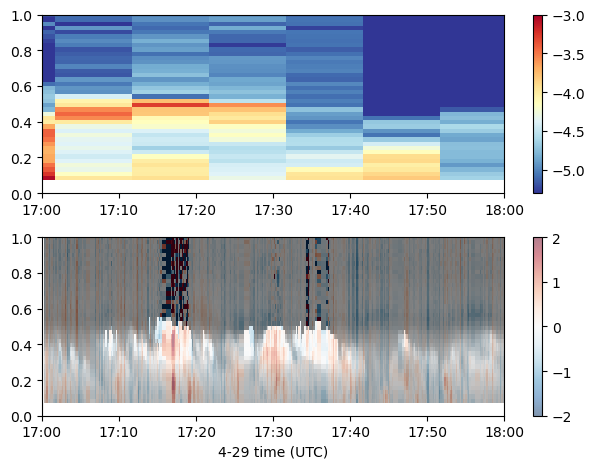

In [ ]:
xlim([DateTime(2024, 4, 29, 17), DateTime(2024,4,29,18)])
gcf()

In [ ]:
# loop through ALL chunks, load next file as data is needed
# takes 105 min on laptop

# VN correction only <==> MDV_FALLBACK=false; MDV_STRICT=false
MDV_FALLBACK = false
MDV_STRICT = true # now do

CALC_SIGMA_ANGLES = false # broken. set to false!
PLOT_STRUCTURE_FN = false

if false # | true # do not rerun!
    # periodic buffer for data
    nx = 4000
    nz = 80
    nbinmax = 25
    beams = init_periodic_beams(nx, nz)

    # TKE dissipation output data array for chunks
    D2_tmp      = Array{Union{Missing,Float64}}(missing, length(iens), nz, nbinmax)
    rho_tmp     = Array{Union{Missing,Float64}}(missing, length(iens), nz, nbinmax)
    epsi_tmp = zeros(Float64, length(iens), nz) .- 9 # -9 is missing
    # fit quality metrics (saved alongside epsilon)
    A_tmp       = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    se_A_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    nbins_tmp   = zeros(Int, length(iens), nz)
    nrho_tmp    = zeros(Int, length(iens), nz)
    R2_tmp      = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    RMSE_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    A_lo_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    A_hi_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    epsi_lo_tmp = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    epsi_hi_tmp = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    sigma_pitch_tmp = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
    sigma_roll_tmp  = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)

    ifile_loaded = 0

    # loop all chunk time indices, record missing for no Vn data
    for ic in eachindex(dtime_st)
        ist = ists[ic]
        ien = iens[ic]

        # map this chunk to its start file
        ifile_needed = findlast(bigind_file_starts .<= ist)
        isnothing(ifile_needed) && error("No file contains ist=$ist")

        # initialize so first load can jump directly toward needed file
        if ifile_loaded == 0
            ifile_loaded = ifile_needed - 1
            bigind_file_end = 0
        end

        # load one or more files until this chunk [ist, ien] is fully available in beams
        while (ifile_loaded < ifile_needed) || (ien > bigind_file_end)
            ifile_loaded += 1
            if ifile_loaded > length(ff)
                error("Ran out of files while loading chunk ic=$ic, ist=$ist, ien=$ien")
            end

            bigind_file_start = bigind_file_starts[ifile_loaded]
            bigind_file_end   = bigind_file_ends[ifile_loaded]

            h  = read_lidar.read_streamlinexr_head(ff[ifile_loaded])
            bb = bigind_file_start:bigind_file_end
            read_streamlinexr_stare!(ff[ifile_loaded], h, beams, bb)

            println("\nic=$ic ifile_loaded=$ifile_loaded bigind_file=$bigind_file_start-$bigind_file_end")
        end
        print("$(ist)-$(ien) ")

        dt_chunk = LidarDt["dtime"][ist] # start time of this chunk
        dopplervel, pitch, roll, _, _, _, Ur, Vr, _ = read_stare_chunk(dt_chunk, beams, Vn, UV, ist, ien)
        # fallback Ur, Vr with interpolated radiosonde relative wind speed...
        chunk_te = dt2te(dt_chunk) # time elapsed of chunk (s since 2024-4-28 00:00:00)
        # time_interp_vector((te_sonde, var_sonde), t) interpolates var_sonde to time t based on te_sonde
        Usnd_chunk = time_interp_vector((snd_te, usonde), chunk_te) # height vector
        Vsnd_chunk = time_interp_vector((snd_te, vsonde), chunk_te)
        # interpolate ship relative wind to chunk time
        uog_chunk = time_interp_vector((psl_te, uog), chunk_te) # scalar
        vog_chunk = time_interp_vector((psl_te, vog), chunk_te)
        Urelsnd_chunk = Usnd_chunk .- uog_chunk # relative wind
        Vrelsnd_chunk = Vsnd_chunk .- vog_chunk
        # average sounding with lidar U, or use whichever is available if one is missing
        for iz in axes(Ur)[2]
            for i in axes(Ur)[1]
                Ur[i,iz] = avg_good(Ur[i,iz], Urelsnd_chunk[iz])
                Vr[i,iz] = avg_good(Vr[i,iz], Vrelsnd_chunk[iz])
            end
        end

        # use vn2_aligned (synced heave) when available; fall back to mdv
        vn2_aligned, pitch_aligned, roll_aligned = load_vn2_aligned(ic, ist, ien, LidarDt["dtime"])

        if CALC_SIGMA_ANGLES
            # fails when angles are missing
            σ_pitch = π / 180 * std( pitch_aligned[isfinite.(pitch_aligned)] ) # radians
            σ_roll  = π / 180 * std( roll_aligned[ isfinite.( roll_aligned)] )
        else
            σ_pitch = π / 180 * 2.0 # nominal 2 degree -> radians
            σ_roll  = π / 180 * 2.0
        end

        if !MDV_STRICT && any(isfinite, vn2_aligned)
            heave = vn2_aligned
            pitch = pitch_aligned # use VN synced angles
            roll = roll_aligned
        elseif MDV_STRICT || MDV_FALLBACK # fallback to mdv-based heave estimate
            valid_dv = isgoodnum.(dopplervel)
            jj = vec(all(valid_dv, dims=1))
            heave = any(jj) ? mean(dopplervel[:, jj], dims=2)[:] : fill(NaN, size(dopplervel, 1))
            pitch[:] .= 0 .* pitch  # zero pitch and roll if not using synced VN
            roll[:]  .= 0 .* roll
        else
            epsi_tmp[ic, :] .= -5 # code for missing heave data (both vn2_aligned and mdv fallback)
            continue # skip this chunk if vn2_aligned is not available, rather than using mdv fallback
        end

        if any(isgoodnum.(Ur)) && any(isgoodnum.(Vr)) # there is wind data
            len = minimum((
                size(dopplervel, 1),
                length(pitch),
                length(roll),
                size(Ur, 1),
                size(Vr, 1),
                length(heave),
            ))
            if len < 3
                epsi_tmp[ic, :] .= -3
                nbins_tmp[ic, :] .= 0
                continue
            end

            w = dopplervel[1:len, :] .- heave[1:len]
            D2bin, rhobin, A_fit, noise, R2_fit, RMSE_fit, nbins_fit, se_A_fit, A_ci_lo, A_ci_hi, epsi_ci_lo, epsi_ci_hi, nrho = 
                D2_rho_stare_qc(w, pitch[1:len]*pi/180, roll[1:len]*pi/180,
                                Ur[1:len, :], Vr[1:len, :],
                                σ_pitch, σ_roll )

            nb = size(D2bin, 1)
            D2_tmp[ ic, :, 1:nb] .= D2bin'
            rho_tmp[ic, :, 1:nb] .= rhobin'

            A_tmp[ic, :] .= A_fit
            se_A_tmp[ic, :] .= se_A_fit
            nbins_tmp[ic, :] .= nbins_fit
            R2_tmp[ic, :] .= R2_fit
            RMSE_tmp[ic, :] .= RMSE_fit
            A_lo_tmp[ic, :] .= A_ci_lo
            nrho_tmp[ic, :] .= nrho
            A_hi_tmp[ic, :] .= A_ci_hi
            epsi_lo_tmp[ic, :] .= epsi_ci_lo
            epsi_hi_tmp[ic, :] .= epsi_ci_hi
            sigma_pitch_tmp[ic, :] .= σ_pitch
            sigma_roll_tmp[ic, :] .= σ_roll

            for iz in eachindex(A_fit)
                a = A_fit[iz]
                if ismissing(a)
                    epsi_tmp[ic, iz] = -3   # code for missing/insufficient structure-function fit
                elseif a >= 0
                    epsi_tmp[ic, iz] = epsilon(a)
                else
                    epsi_tmp[ic, iz] = -1   # code for slope A <= 0
                end
            end
        else
            epsi_tmp[ic, :] .= -4           # code for missing wind (only this chunk)
            nbins_tmp[ic, :] .= 0
        end
    end

    # save: epsilon plus fit metrics
    epsi = epsi_tmp
    height = beams[:height]
    A = A_tmp
    se_A = se_A_tmp
    nbins = nbins_tmp
    nrho = nrho_tmp
    sigma_pitch = sigma_pitch_tmp
    sigma_roll = sigma_roll_tmp
    savetime = Dates.format(now(), dateformat"yyyymmdd_HHMM")
    @save joinpath("epsilon_data","epsi_stare_vn_chunks_r$(savetime).jld") epsi dtime_st dtime_en height A se_A nbins R2_tmp RMSE_tmp A_lo_tmp A_hi_tmp epsi_lo_tmp epsi_hi_tmp nrho sigma_pitch sigma_roll
end


In [ ]:
# investigate cause of low rho in input variables for high-epsilon chunk times

# interpolate the relative wind to chunk time as in the production loop
# iz = 7 # height (nr 240 m)
# synchronize clocks using the previously calculated offset function
lidar_clock_fast_by(t) = Millisecond( round(Int64, 1_000 * fit_offset(t)) )
adj_lidar(t) = t .- lidar_clock_fast_by(t[1])

#for ic in eachindex(ists)[213:213]
ic = 213
    ist = ists[ic]
    ien = iens[ic]
    # read the stare chunk to get the Ur, Vr that are used as input to the structure function calculation
    dt_chunk = adj_lidar(LidarDt["dtime"][ist:ien])
    # read Ur,Vrdirectly from UV withOUT read_stare_chunk
    # _, _, _, _, _, _, Ur, Vr, _ = read_stare_chunk(dt_chunk, beams, Vn, UV, ist, ien)
    Ur = Matrix{Union{Missing,Float64}}(missing, size(UV[:ur])) # allocates for every chunk
    Vr = Matrix{Union{Missing,Float64}}(missing, size(UV[:vr]))
    
    # chunks.get_mean_uv_chunk!(Ur,Vr, UV, dt_chunk) # update Ur, Vr in-place
    # vector vs scalar time indices confusion abounds!
    
    ind = findindices( Dates.value.(dt_chunk), Dates.value.(UV["time"]))
    # result must be 1:1 for dt_chunk and ind
    ls = length(dt_chunk)
    li = length(ind)
    ls == li

true

In [ ]:
# postproduction compute epsilon uncertainties

timestamps = [ "20260517_1959",
               "20260517_2352"  ]

for timestamp in timestamps
    # latest_file = last(sort(
    #     filter(f -> startswith(f, filtstring) && endswith(f, ".jld"), readdir("epsilon_data"))))
    latest_file = "epsi_stare_vn_chunks_r$(timestamp).jld"
    outfile = joinpath("epsilon_data", latest_file)
    res = load_se_epsilon_jld(outfile) # not a Dict, but a NamedTuple with keys: se_epsilon, rel_se_epsilon, A, se_A, epsi

    s_se = finite_summary(res.se_epsilon)
    s_rel = finite_summary(res.rel_se_epsilon)

    jldsave(joinpath("epsilon_data", "epsi_se_r$(timestamp).jld"), s_se=s_se)

    @info "loaded" outfile
    @printf("se_epsilon:      n=%d p50=%s p90=%s p99=%s\n", s_se.n, string(s_se.p50), string(s_se.p90), string(s_se.p99))
    @printf("se_epsilon/epsi: n=%d p50=%s p90=%s p99=%s\n", s_rel.n, string(s_rel.p50), string(s_rel.p90), string(s_rel.p99))
end

┌ Info: loaded
│   outfile = epsilon_data/epsi_stare_vn_chunks_r20260517_1959.jld
└ @ Main /Users/deszoeks/Projects/lidar/ASTRAL2024/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y602sZmlsZQ==.jl:18


se_epsilon:      n=99371 p50=8.801780864853236e-6 p90=0.00012247239966107205 p99=0.004487464326094792
se_epsilon/epsi: n=99371 p50=0.14525689226309096 p90=0.6777716452646324 p99=4.904908402829636


┌ Info: loaded
│   outfile = epsilon_data/epsi_stare_vn_chunks_r20260517_2352.jld
└ @ Main /Users/deszoeks/Projects/lidar/ASTRAL2024/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y602sZmlsZQ==.jl:18


se_epsilon:      n=162005 p50=5.739177903170524e-6 p90=8.474468390752999e-5 p99=0.001790116183791282
se_epsilon/epsi: n=162005 p50=0.0929701198887024 p90=0.3778485009618615 p99=1.1767455091398609


In [ ]:
timestamps = [ "20260505_1508",
               "20260506_1233",
               "20260507_0712",
               "20260507_0005",
               "20260508_0919",
               "20260508_1212",
               "20260515_2252",
               "20260517_1959",
               "20260517_2352" ]

timestamp = timestamps[5]
latest_file = "epsi_stare_vn_chunks_r$(timestamp).jld"
outfile = joinpath("epsilon_data", latest_file)
data = load(outfile) # dict

dtime_st = data["dtime_st"] # truncated
dtime_en = data["dtime_en"]
height   = data["height"]
epsi     = data["epsi"]
nbins    = data["nbins"]

last(data["dtime_st"])

2024-06-13T06:43:57.960

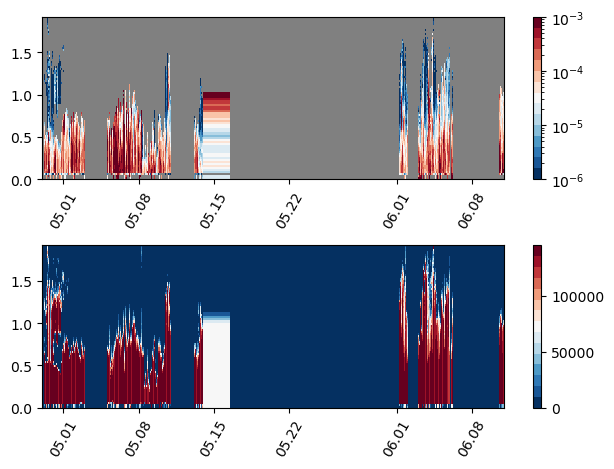

In [ ]:
@load "epsilon_data/epsi_stare_vn_chunks_r20260517_1959.jld" epsi nbins nrho

idx = map(c-> c[1], findall( any(epsi .> 0, dims=2) ) ) # any chunk has data that is not missing
# mask = nbins .> 12
mask = nrho .> 50_000 # good

xlims = [ DateTime("2024-04-29T00:00:00"), DateTime("2024-06-11T00:00:00") ]

cmap = PythonPlot.matplotlib.cm.get_cmap("RdBu_r", 15)
norm = PythonPlot.matplotlib.colors.LogNorm(vmin=1e-6, vmax=1e-3)

clf()
subplot(2,1,1)
pcolormesh( dtime_en, height./1e3, pd(max.(0,mask.*epsi)),
    cmap=cmap, norm=norm)
colorbar()
xlim(xlims)
ax = gca()
ax.set_facecolor("gray")
ax.xaxis.set_major_formatter(PythonPlot.matplotlib.dates.DateFormatter("%m.%d"))
PythonPlot.matplotlib.pyplot.setp(ax.get_xticklabels(), rotation=60) #, ha="right")

subplot(2,1,2)
pcolormesh( dtime_en, height./1e3, pd(nrho), cmap=cmap, vmin=0 )
colorbar()
xlim(xlims)
ax = gca()
ax.xaxis.set_major_formatter(PythonPlot.matplotlib.dates.DateFormatter("%m.%d"))
PythonPlot.matplotlib.pyplot.setp(ax.get_xticklabels(), rotation=60) #, ha="right")

tight_layout()
gcf()
